#Import + Load Clean Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load parquet file
df = pd.read_parquet("../data/processed/retail_clean.parquet")

print("Shape:", df.shape)
df.head()


Shape: (131706, 8)


,Unnamed: 0,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount
0,1,02/01/2016,2547,1,X52,0EM7L,1.0,3.13
1,2,02/01/2016,822,2,2ML,68BRQ,1.0,5.46
2,3,02/01/2016,3686,3,0H2,CZUZX,1.0,6.35
3,4,02/01/2016,3719,4,0H2,549KK,1.0,5.59
4,5,02/01/2016,9200,5,0H2,K8EHH,1.0,6.88


#Basic Overview

In [2]:
# Summary stats
df.describe(include="all").T.head(15)

# Unique values per column
df.nunique().sort_values(ascending=False).head(10)

# Missing values check (just in case)
df.isna().sum().sort_values(ascending=False).head(10)


Unnamed: 0        0
Date              0
Customer_ID       0
Transaction_ID    0
SKU_Category      0
SKU               0
Quantity          0
Sales_Amount      0
dtype: int64

#Sales Over Time

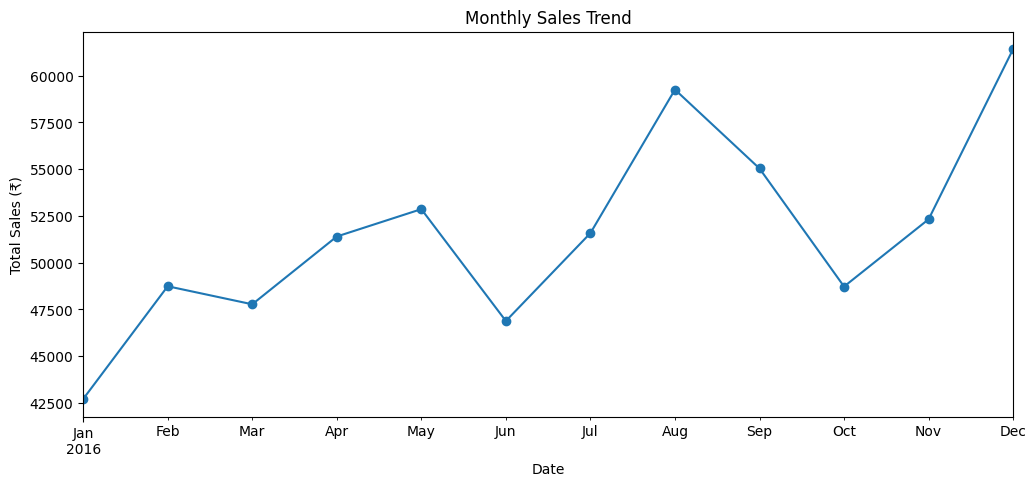

C:\Users\Abhay\AppData\Local\Temp\ipykernel_19400\290267965.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")


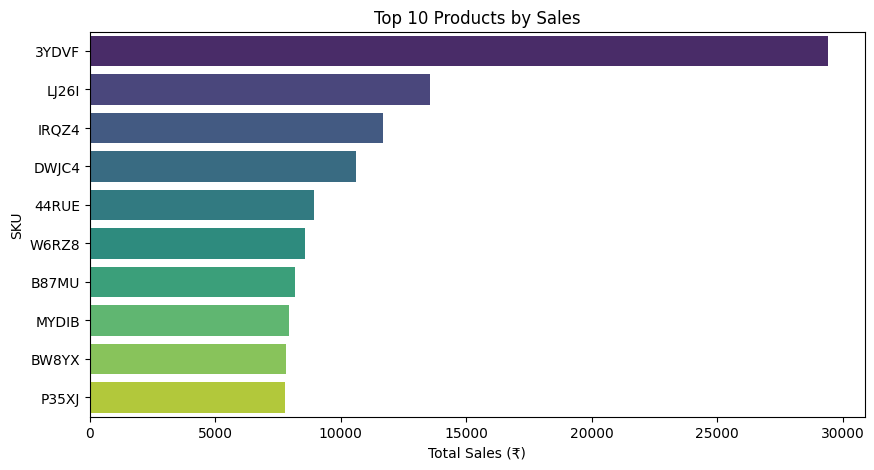

C:\Users\Abhay\AppData\Local\Temp\ipykernel_19400\290267965.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index, palette="mako")


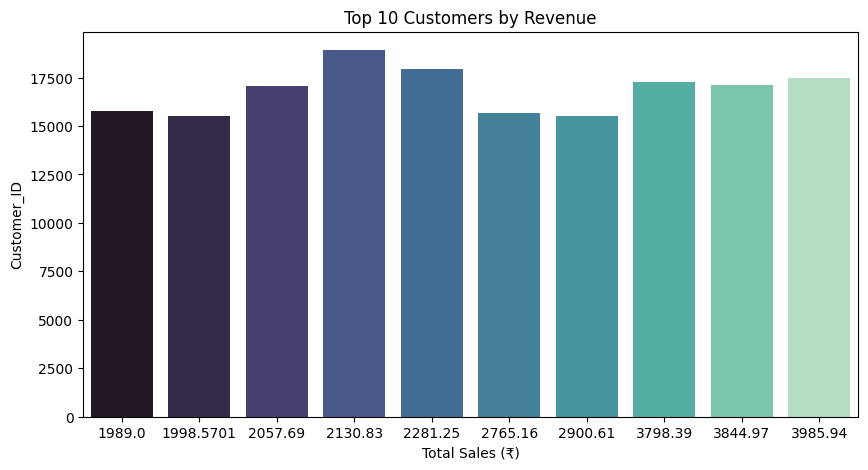

C:\Users\Abhay\AppData\Local\Temp\ipykernel_19400\290267965.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette="Set2")


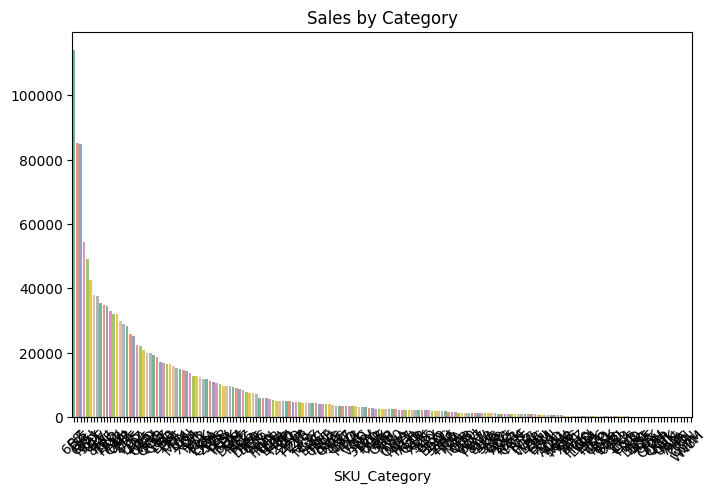

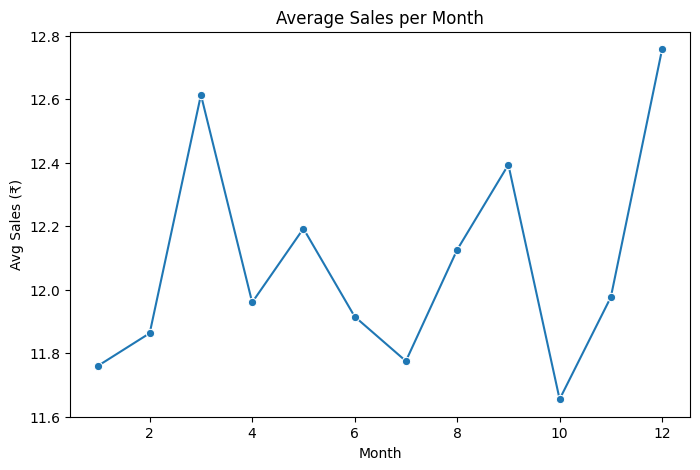

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load parquet file
df = pd.read_parquet("../data/processed/retail_clean.parquet")

# ---- 1. Convert Date ----
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# ---- 2. Sales Over Time ----
sales_trend = df.groupby(df['Date'].dt.to_period("M"))['Sales_Amount'].sum()

sales_trend.plot(kind="line", figsize=(12,5), marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales (₹)")
plt.show()

# ---- 3. Top Products ----
top_products = df.groupby("SKU")["Sales_Amount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales (₹)")
plt.show()

# ---- 4. Top Customers ----
top_customers = df.groupby("Customer_ID")["Sales_Amount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_customers.values, y=top_customers.index, palette="mako")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Sales (₹)")
plt.show()

# ---- 5. Sales by Category ----
category_sales = df.groupby("SKU_Category")["Sales_Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette="Set2")
plt.title("Sales by Category")
plt.xticks(rotation=45)
plt.show()

# ---- 6. Seasonal Analysis ----
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby("Month")["Sales_Amount"].mean()

plt.figure(figsize=(8,5))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker="o")
plt.title("Average Sales per Month")
plt.xlabel("Month")
plt.ylabel("Avg Sales (₹)")
plt.show()




In [5]:
df.columns


Index(['Unnamed: 0', 'Date', 'Customer_ID', 'Transaction_ID', 'SKU_Category',
       'SKU', 'Quantity', 'Sales_Amount'],
      dtype='object')